<a href="https://colab.research.google.com/github/mbenedicto99/Natural-Language-Processing/blob/main/PECE_2026_POS_tagging_e_depend%C3%AAncias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marcos Lopes (PECE/USP) -- 2026

# Mac-Morpho

Corpus de sentenças cuja fonte são notícias da Folha de S. Paulo no ano de 1994. Etiquetado morfossintaticamente por humanos (padrão ouro).

In [1]:
# Download do corpus

import nltk
nltk.download('mac_morpho')

[nltk_data] Downloading package mac_morpho to /root/nltk_data...
[nltk_data]   Unzipping corpora/mac_morpho.zip.


True

In [2]:
# Uso das sentenças não etiquetadas (como se fosse um corpus de texto "puro")

sents = nltk.corpus.mac_morpho.sents()
sents[:2]

[['Jersei',
  'atinge',
  'média',
  'de',
  'Cr$',
  '1,4',
  'milhão',
  'em',
  'a',
  'venda',
  'de',
  'a',
  'Pinhal',
  'em',
  'São',
  'Paulo'],
 ['Programe',
  'sua',
  'viagem',
  'a',
  'a',
  'Exposição',
  'Nacional',
  'do',
  'Zebu',
  ',',
  'que',
  'começa',
  'dia',
  '25']]

In [3]:
# Palavras etiquetadas

palavras_etiquetas = nltk.corpus.mac_morpho.tagged_words()
print(palavras_etiquetas[:5])
print(len(palavras_etiquetas))

[('Jersei', 'N'), ('atinge', 'V'), ('média', 'N'), ('de', 'PREP'), ('Cr$', 'CUR')]
1170095


# Criação de um etiquetador morfossintático (POS-tagger)

Impressione seus amigos com um POS-tagger criado inteiramente por você -- e com três linhas de código!

Antes de começar, vamos aprender a usar o método `get()` dos dicionários do Python. Ele oferece dois recursos importantes:

* Quando se consulta uma chave inexistente, ele não retorna um erro;
* O método permite que seja declarado um valor por default que será automaticamente retornado quando são buscadas chaves inexistentes.

In [4]:
d = {'abacate': 'n', 'beber': 'v'}

In [5]:
d['beber']

'v'

In [17]:
# Lembre-se: chamar uma chave inexistente no dicionário dá erro
d['beber']

'v'

In [18]:
# Uma solução para o erro de chave é usar o método dict.get()

d = {'abacate': 'n', 'beber': 'v'}
print(d.get('beber', 'Chave desconhecida.'))
print(d.get('uva', 'Chave desconhecida.'))

v
Chave desconhecida.


In [19]:
# Criação do dicionário de etiquetas por Compreensão de Dicionário (não de lista)

dic_pos = {palavra.lower(): pos for (palavra, pos) in palavras_etiquetas}
print(len(dic_pos))
dic_pos['média']

59911


'ADJ'

In [20]:
# Criação de uma função de etiquetagem simplificada,
# baseada no dicionário de etiquetas

def tag(sentenca: str) -> list:
    palavras = sentenca.lower().split()
    return [(p, dic_pos.get(p, '<??>')) for p in palavras]

In [21]:
# Experimente!

tag('Não consigo pensar em uma sentença com uma palavra que não exista no meio daquele um milhão de palavras')

[('não', 'ADV'),
 ('consigo', 'V'),
 ('pensar', 'V'),
 ('em', 'PREP|+'),
 ('uma', 'ART'),
 ('sentença', 'N'),
 ('com', 'PREP'),
 ('uma', 'ART'),
 ('palavra', 'N'),
 ('que', 'KS'),
 ('não', 'ADV'),
 ('exista', 'V'),
 ('no', 'KC'),
 ('meio', 'NUM'),
 ('daquele', '<??>'),
 ('um', 'ART'),
 ('milhão', 'N'),
 ('de', 'PREP'),
 ('palavras', 'N')]

# POS-tagging com spaCy

In [22]:
# Instalação/atualização do spaCy e dos modelos de língua
!pip install -U spacy

!python -m spacy download pt_core_news_sm  # Notar o "sm": Small Model

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 35.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
# Importação do módulo e do modelo de língua
import spacy
nlp = spacy.load('pt_core_news_sm')

In [24]:
# Documento de exemplo
texto = 'Águas passadas não movem moinhos'

In [25]:
# Outro exemplo bobo, mas que mostra que a POS de uma palavra (ex. "francês")
# é alterada conforme o contexto (substantivo ou adjetivo)

texto = 'O pão francês não foi entregue hoje.'

In [26]:
doc = nlp(texto)

In [27]:
for token in doc:
    print(token.text, token.pos_)

O DET
pão NOUN
francês ADJ
não ADV
foi AUX
entregue VERB
hoje ADV
. PUNCT


# Análise de Dependências

In [28]:
doc = nlp('João chutou a bola.')
for token in doc:
    print(token.text, token.dep_)

João nsubj
chutou ROOT
a det
bola obj
. punct


In [29]:
# Exibição gráfica das dependências
from spacy import displacy

displacy.render(doc, style='dep', jupyter=True)

In [30]:
# Caso você queira gravar a imagem gerada em arquivo...
from pathlib import Path

svg = displacy.render(doc, style='dep', jupyter=False)
output_path = Path('Minha Sentença.svg')
lixo = output_path.open('w', encoding='utf-8').write(svg)

# Exemplos de aplicação

Esses exemplos vão servir de base para a solução da tarefa de Linguística Forense.

In [31]:
import pandas as pd

In [32]:
# Opcional: Barras de progresso (para você não achar que a execução travou...)

from tqdm.notebook import tqdm
tqdm.pandas()

In [33]:
from google.colab import files

uploaded = files.upload()

Saving DomCasmurro.txt to DomCasmurro.txt
Saving Abolicionismo.txt to Abolicionismo.txt
Saving LivroApócrifo.txt to LivroApócrifo.txt
Saving Guarani.txt to Guarani.txt


In [34]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize


def ler(nome_arquivo) -> str:
    with open(nome_arquivo) as arquivo:
        return arquivo.read()


# Tokenização de palavras
def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='portuguese')


# Tokenização de sentenças
def tokenizar_sentencas(txt: str) -> list:
    txt = txt.replace('\n', ' ')
    return sent_tokenize(txt, language='portuguese')


# Limpeza simples
def limpar(lista: list) -> list:
    return [i.lower() for i in lista if i.isalpha()]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [35]:
texto = ler('Guarani.txt')

In [36]:
sents = tokenizar_sentencas(texto)

In [37]:
df_alencar = pd.DataFrame({'Sentencas': sents})
df_alencar.head()

,Sentencas
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ..."
1,O guarani.
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro)."
3,Texto proveniente de: A Biblioteca Virtual do ...
4,Este material pode ser redistribuído livrement...


In [38]:
# O que acontece quando se aplica describe() a strings?

df_alencar.describe()

,Sentencas
count,5778
unique,5571
top,— Oh!
freq,26


In [39]:
# E quanto a contagens de valores?

df_alencar['Sentencas'].value_counts()

,count
Sentencas,
— Oh!,26
— Ah!,17
— Sim!,17
— Não!,10
— Qual?,7
...,...
"Um dia a menina ouvindo chamar-se assim por ele e achando um pretexto para zangar-se contra o escravo humilde que obedecia ao seu menor gesto, repreendeu-o com aspereza: — Por que me chamas tu Ceci?",1
"Ceci era o nome que o índio dava à sua senhora, depois que lhe tinham ensinado que ela se chamava Cecília.",1
"De volta destas expedições corria todo o dia os campos para procurar um perfume, uma flor, um pássaro, que entregava ao fidalgo e pedia-lhe desse a Ceci, pois já não se animava a chegar-se para ela, com receio de desgostá-la.",1


In [40]:
# Um DataFrame tem seus próprios métodos para strings.
# Seu processamento é mais veloz que os equivalentes em Python (compreensão de listas, por ex.)

df_alencar['TamSentencas'] = df_alencar['Sentencas'].str.len()
df_alencar.head()

,Sentencas,TamSentencas
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ...",54
1,O guarani.,10
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro).",44
3,Texto proveniente de: A Biblioteca Virtual do ...,196
4,Este material pode ser redistribuído livrement...,120


In [41]:
# Mais moleza para a sua vida: função que recebe um nome de arquivo
# e retorna um DataFrame de sentenças com seus tamanhos

def textos_df(arq: str) -> pd.DataFrame:
    txt = ler(arq)
    sentencas = tokenizar_sentencas(txt)
    df_obra = pd.DataFrame({'Sentencas': sentencas})
    df_obra['TamSentencas'] = df_obra['Sentencas'].str.len()

    return df_obra

In [42]:
# Exemplos de aplicação

df_nabuco = textos_df('Abolicionismo.txt')
df_nabuco.head()

,Sentencas,TamSentencas
0,"O Abolicionismo, de Joaquim Nabuco Fonte: NABU...",58
1,O abolicionismo.,16
2,"São Paulo : Publifolha, 2000.",29
3,(Grandes nomes do pensamento brasileiro da Fol...,63
4,Texto proveniente de: A Biblioteca Virtual do ...,196


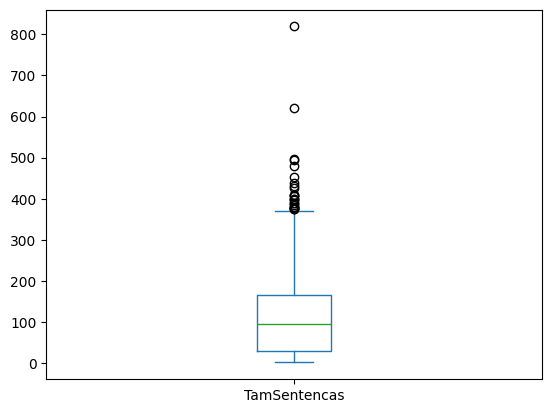

In [43]:
# Uma visualização rápida dos dados numéricos do DataFrame através de um Box Plot

df_alencar.plot.box();

In [44]:
# Função que recebe uma string e retorna o número de advérbios encontrados nela

def n_advs(sent: str) -> list:
    doc = nlp(sent)
    return len([t.pos_ for t in doc if t.pos_ == 'ADV'])

In [45]:
n_advs('Teste de não dar nunca nada certo certamente.')

3

In [46]:
# Aplicação da função a um df

df_alencar['Advs'] = df_alencar['Sentencas'].progress_apply(n_advs)
df_alencar.sample()  # Para exemplificar

  0%|          | 0/5778 [00:00<?, ?it/s]

,Sentencas,TamSentencas,Advs
2772,— Tanto tempo há que suplico-vos!,33,0


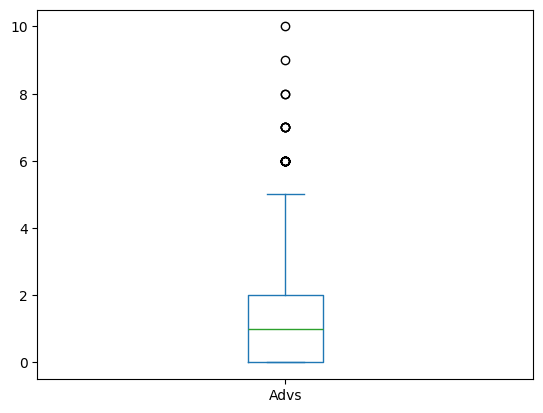

In [47]:
# Box Plot para os advérbios (semelhante aos de tamanhos de sentenças)

df_alencar['Advs'].plot.box();

In [48]:
# O módulo matplotlib oferece mais poder e versatilidade com gráficos que o Pandas
# Com ele, fica fácil gerar gráficos diretamente de listas, como faremos a seguir

import matplotlib.pyplot as plt

In [49]:
df_nabuco.head()

,Sentencas,TamSentencas
0,"O Abolicionismo, de Joaquim Nabuco Fonte: NABU...",58
1,O abolicionismo.,16
2,"São Paulo : Publifolha, 2000.",29
3,(Grandes nomes do pensamento brasileiro da Fol...,63
4,Texto proveniente de: A Biblioteca Virtual do ...,196


In [50]:
# Vamos acrescentar uma coluna de advérbios aos demais DFs

df_nabuco['Advs'] = df_nabuco['Sentencas'].progress_apply(n_advs)

  0%|          | 0/1842 [00:00<?, ?it/s]

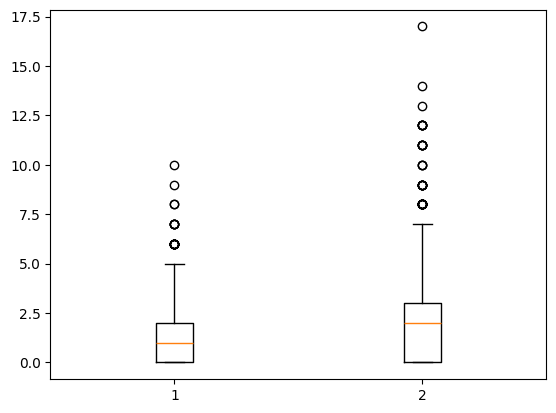

In [51]:
# Agora, será possível compará-los por box plots

adverbios = [i['Advs'].values.tolist() for i in [df_alencar, df_nabuco]]
plt.boxplot(adverbios);

# Tarefa: Linguística Forense

Seu grupo de especialistas em PLN foi chamado para periciar um livro escrito por um autor incógnito. Há três elementos suspeitos de ser o autor da obra. Todos negam veementemente a autoria, mas sabe-se que o autor é um deles. Os suspeitos são:

* Machado de Assis, autor de "Dom Casmurro"
* José de Alencar, autor de "O Guarani"
* Joaquim Nabuco, autor de "O Abolicionismo"

Você tem à disposição esses três livros para comparar com o livro apócrifo.

Em suas análises, use alguns dos recursos comuns da Linguística Forense:

* Análise das divisões de período. Você pode usar somente o tamanho das sentenças, para simplificar, mas uma análise mais completa incluiria todos os delimitadores (vírgula, ponto-e-vírgula, dois pontos, travessão, parênteses...);
* Comparação das colocações adverbiais, em especial os modais (etiqueta de dependência: "advmod") e as conjunções subordinativas ("que" e "se"; etiqueta: "sconj").

A solução do problema deve ser representada num gráfico com duas ou três dimensões, em que cada dimensão expressa uma métrica de comparação, como divisão de período / advérbios modais, por exemplo.

Ao final, responda: quem é o autor do livro apócrifo?

In [52]:
# Montar os DataFrames

import pandas as pd

df_alencar = textos_df('Guarani.txt')
df_machado = textos_df('DomCasmurro.txt')
df_nabuco  = textos_df('Abolicionismo.txt')
df_apocrifo = textos_df('LivroApócrifo.txt')

obras = {
    'Alencar': df_alencar,
    'Machado': df_machado,
    'Nabuco': df_nabuco,
    'Apócrifo': df_apocrifo
}

In [53]:
# extrair métricas forenses

from collections import Counter
from tqdm.notebook import tqdm
tqdm.pandas()

def analisar_sentenca(sent: str) -> dict:
    doc = nlp(sent)

    n_tokens = 0
    n_adv = 0
    n_advmod = 0
    n_sconj = 0
    n_que = 0
    n_se = 0
    n_virgulas = sent.count(',')
    n_pontoevirg = sent.count(';')
    n_dois_pontos = sent.count(':')
    n_travessoes = sent.count('—') + sent.count('-')

    for tok in doc:
        if tok.is_space:
            continue

        n_tokens += 1

        if tok.pos_ == 'ADV':
            n_adv += 1

        if tok.dep_ == 'advmod':
            n_advmod += 1

        if tok.pos_ == 'SCONJ':
            n_sconj += 1

        if tok.text.lower() == 'que':
            n_que += 1

        if tok.text.lower() == 'se':
            n_se += 1

    return {
        'Tokens': n_tokens,
        'Advs': n_adv,
        'AdvMods': n_advmod,
        'Sconj': n_sconj,
        'Que': n_que,
        'Se': n_se,
        'Virgulas': n_virgulas,
        'PontoEVirg': n_pontoevirg,
        'DoisPontos': n_dois_pontos,
        'Travesseiros': n_travessoes
    }

In [54]:
# Aplicar nas 4 obras

def enriquecer_df(df):
    analises = df['Sentencas'].progress_apply(analisar_sentenca)
    analises_df = pd.DataFrame(list(analises))
    return pd.concat([df.reset_index(drop=True), analises_df], axis=1)

df_alencar = enriquecer_df(df_alencar)
df_machado = enriquecer_df(df_machado)
df_nabuco = enriquecer_df(df_nabuco)
df_apocrifo = enriquecer_df(df_apocrifo)

obras = {
    'Alencar': df_alencar,
    'Machado': df_machado,
    'Nabuco': df_nabuco,
    'Apócrifo': df_apocrifo
}

  0%|          | 0/5778 [00:00<?, ?it/s]

  0%|          | 0/4263 [00:00<?, ?it/s]

  0%|          | 0/1842 [00:00<?, ?it/s]

  0%|          | 0/1938 [00:00<?, ?it/s]

In [55]:
# criar um resumo por obra

def resumo_obra(nome, df):
    total_tokens = df['Tokens'].sum()

    return {
        'Obra': nome,
        'Sentencas': len(df),
        'MediaTamSent': df['TamSentencas'].mean(),
        'MedianaTamSent': df['TamSentencas'].median(),
        'DesvioTamSent': df['TamSentencas'].std(),
        'Advs_por_1000': df['Advs'].sum() / total_tokens * 1000 if total_tokens else 0,
        'AdvMods_por_1000': df['AdvMods'].sum() / total_tokens * 1000 if total_tokens else 0,
        'Sconj_por_1000': df['Sconj'].sum() / total_tokens * 1000 if total_tokens else 0,
        'Que_por_1000': df['Que'].sum() / total_tokens * 1000 if total_tokens else 0,
        'Se_por_1000': df['Se'].sum() / total_tokens * 1000 if total_tokens else 0,
        'Virgulas_por_1000': df['Virgulas'].sum() / total_tokens * 1000 if total_tokens else 0,
        'PontoEVirg_por_1000': df['PontoEVirg'].sum() / total_tokens * 1000 if total_tokens else 0,
        'DoisPontos_por_1000': df['DoisPontos'].sum() / total_tokens * 1000 if total_tokens else 0
    }

resumo = pd.DataFrame([resumo_obra(nome, df) for nome, df in obras.items()])
resumo

,Obra,Sentencas,MediaTamSent,MedianaTamSent,DesvioTamSent,Advs_por_1000,AdvMods_por_1000,Sconj_por_1000,Que_por_1000,Se_por_1000,Virgulas_por_1000,PontoEVirg_por_1000,DoisPontos_por_1000
0,Alencar,5778,106.943233,95.0,81.664730,44.545557,40.003531,28.383649,34.370135,8.747011,57.898791,19.058854,3.193863
1,Machado,4263,92.773164,76.0,92.542987,64.722954,58.189943,37.655888,31.997183,6.824447,85.305582,13.211740,2.877925
2,Nabuco,1842,210.380565,179.5,162.108999,51.756337,47.746560,28.878636,30.114526,8.074483,80.703634,7.319217,3.185850
3,Apócrifo,1938,111.441692,101.0,87.783155,33.990593,31.812600,25.255451,25.904215,6.788851,58.944832,9.916819,3.406010


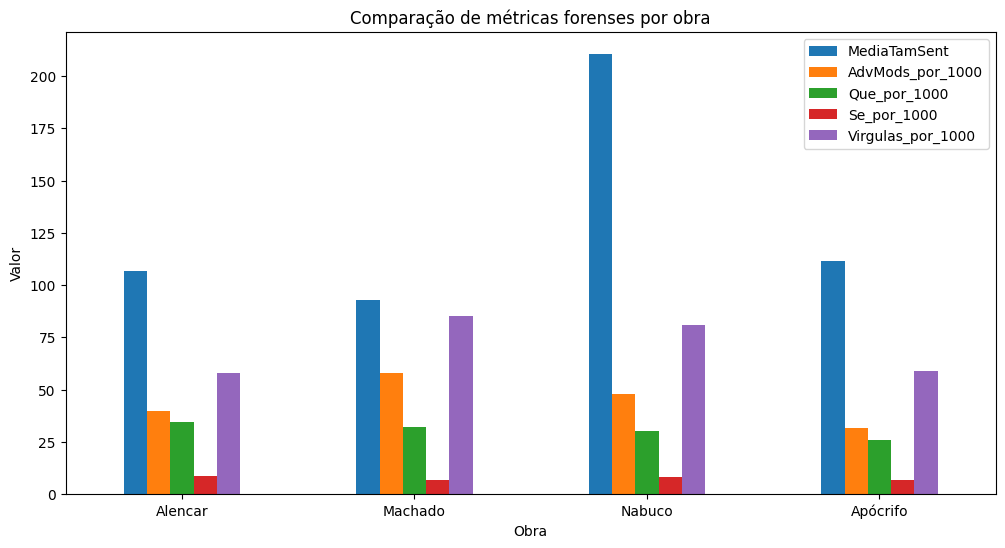

In [56]:
# métricas principais

import matplotlib.pyplot as plt

cols = [
    'MediaTamSent',
    'AdvMods_por_1000',
    'Que_por_1000',
    'Se_por_1000',
    'Virgulas_por_1000'
]

ax = resumo.set_index('Obra')[cols].plot(kind='bar', figsize=(12,6))
ax.set_title('Comparação de métricas forenses por obra')
ax.set_ylabel('Valor')
plt.xticks(rotation=0)
plt.show()

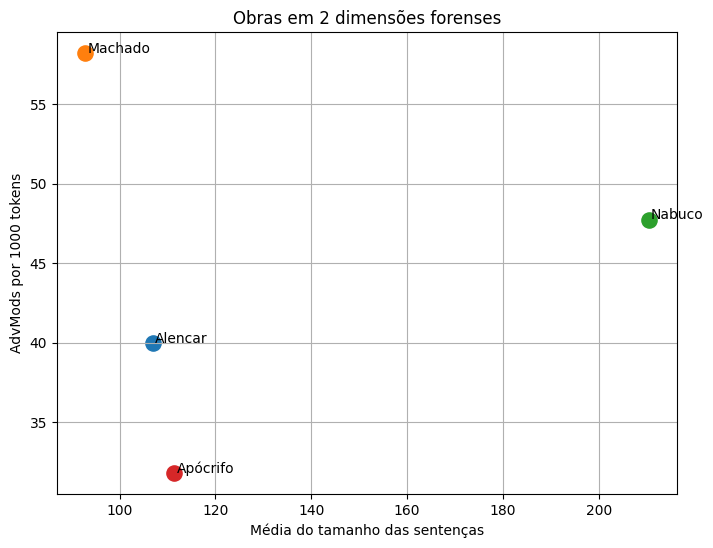

In [57]:
# dispersão em 2 dimensões

plt.figure(figsize=(8,6))

x = resumo['MediaTamSent']
y = resumo['AdvMods_por_1000']

for _, row in resumo.iterrows():
    plt.scatter(row['MediaTamSent'], row['AdvMods_por_1000'], s=120)
    plt.text(row['MediaTamSent'] + 0.5, row['AdvMods_por_1000'] + 0.02, row['Obra'])

plt.xlabel('Média do tamanho das sentenças')
plt.ylabel('AdvMods por 1000 tokens')
plt.title('Obras em 2 dimensões forenses')
plt.grid(True)
plt.show()

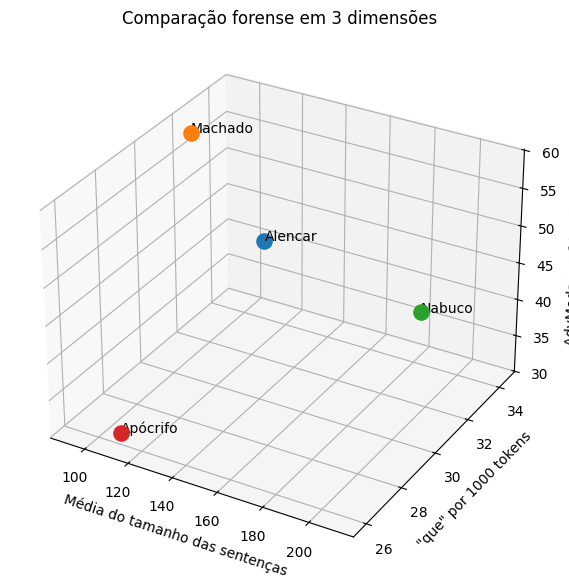

In [58]:
# dispersão em 3 dimensões

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

xs = resumo['MediaTamSent']
ys = resumo['Que_por_1000']
zs = resumo['AdvMods_por_1000']

for _, row in resumo.iterrows():
    ax.scatter(row['MediaTamSent'], row['Que_por_1000'], row['AdvMods_por_1000'], s=120)
    ax.text(row['MediaTamSent'], row['Que_por_1000'], row['AdvMods_por_1000'], row['Obra'])

ax.set_xlabel('Média do tamanho das sentenças')
ax.set_ylabel('"que" por 1000 tokens')
ax.set_zlabel('AdvMods por 1000 tokens')
ax.set_title('Comparação forense em 3 dimensões')

plt.show()

In [59]:
# medida objetiva de proximidade

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import pandas as pd

features = [
    'MediaTamSent',
    'DesvioTamSent',
    'AdvMods_por_1000',
    'Sconj_por_1000',
    'Que_por_1000',
    'Se_por_1000',
    'Virgulas_por_1000'
]

tmp = resumo[['Obra'] + features].copy()

scaler = StandardScaler()
X = scaler.fit_transform(tmp[features])

dist = pd.DataFrame(
    pairwise_distances(X),
    index=tmp['Obra'],
    columns=tmp['Obra']
)

dist

Obra,Alencar,Machado,Nabuco,Apócrifo
Obra,,,,
Alencar,0.000000,4.299717,4.188869,3.762127
Machado,4.299717,0.000000,4.290641,4.810330
Nabuco,4.188869,4.290641,0.000000,4.501481
Apócrifo,3.762127,4.810330,4.501481,0.000000


In [60]:
dist.loc['Apócrifo', ['Alencar', 'Machado', 'Nabuco']].sort_values()

,Apócrifo
Obra,
Alencar,3.762127
Nabuco,4.501481
Machado,4.810330


In [61]:
# n-gramas de caracteres

import re
from collections import Counter
from math import sqrt

def ler_corpo(arq):
    txt = ler(arq)
    return txt.replace('\n', ' ')

def char_ngrams(txt, n=4):
    txt = re.sub(r'\s+', ' ', txt.lower())
    return Counter(txt[i:i+n] for i in range(len(txt)-n+1))

def cosine_counter(c1, c2):
    inter = set(c1) & set(c2)
    num = sum(c1[k] * c2[k] for k in inter)
    den1 = sqrt(sum(v*v for v in c1.values()))
    den2 = sqrt(sum(v*v for v in c2.values()))
    return num / (den1 * den2)

g_alencar = char_ngrams(ler_corpo('Guarani.txt'))
g_machado = char_ngrams(ler_corpo('DomCasmurro.txt'))
g_nabuco = char_ngrams(ler_corpo('Abolicionismo.txt'))
g_apocrifo = char_ngrams(ler_corpo('LivroApócrifo.txt'))

sim_ngram = pd.Series({
    'Alencar': cosine_counter(g_apocrifo, g_alencar),
    'Machado': cosine_counter(g_apocrifo, g_machado),
    'Nabuco': cosine_counter(g_apocrifo, g_nabuco)
}).sort_values(ascending=False)

sim_ngram

,0
Alencar,0.823339
Machado,0.801451
Nabuco,0.785139


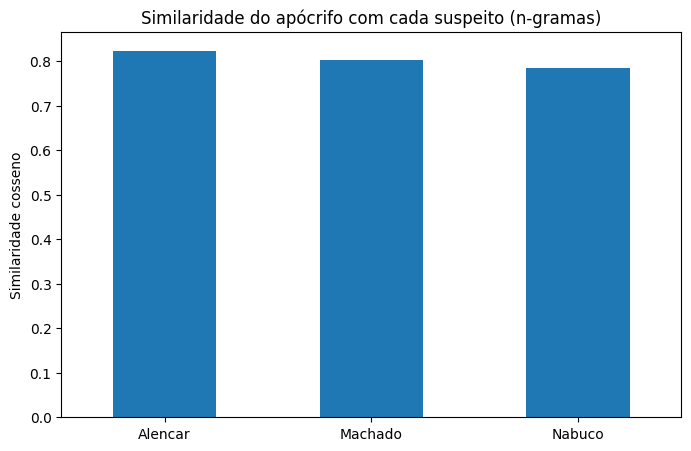

In [62]:
sim_ngram.plot(kind='bar', figsize=(8,5), title='Similaridade do apócrifo com cada suspeito (n-gramas)')
plt.ylabel('Similaridade cosseno')
plt.xticks(rotation=0)
plt.show()

# "Quem é o autor?"

## Conclusão:

A comparação entre as obras foi feita com base em métricas de linguística forense, incluindo tamanho das sentenças, frequência de advérbios modais/modificadores adverbiais, uso de conjunções subordinativas e ocorrência de “que” e “se”. Nos gráficos bidimensional e tridimensional, o Livro Apócrifo se posiciona mais próximo de José de Alencar do que de Machado de Assis e Joaquim Nabuco. O reforço com similaridade de n-gramas de caracteres também aponta maior proximidade estilística com O Guarani. Assim, a hipótese mais plausível é que o autor do livro apócrifo seja José de Alencar.